In [ ]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms

In [ ]:
# data 다운
# https://aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&aihubDataSe=realm&dataSetSn=126 에서 받을 수 있어요

!pip install gdown
!gdown https://drive.google.com/uc?id=14lAjaR2dRp5p5kEsm5GnwNM9KH-VgoOq -O 대화체.xlsx

Downloading...
From: https://drive.google.com/uc?id=14lAjaR2dRp5p5kEsm5GnwNM9KH-VgoOq
To: /content/대화체.xlsx
100% 9.57M/9.57M [00:00<00:00, 187MB/s]


In [ ]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data.loc[idx, '원문'], self.data.loc[idx, '번역문']

In [ ]:
BATCH_SIZE = 8

data = pd.read_excel('대화체.xlsx')
custom_DS = CustomDataset(data)
train_DS, val_DS, test_DS, _ = random_split(custom_DS, [32,16,8, len(custom_DS)-32-16-8])

train_DL = DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

print(len(train_DS))
print(len(val_DS))
print(len(test_DS))

32
16
8


In [ ]:
# train_DL 테스트
src_texts, trg_texts = next(iter(train_DL))

print(src_texts)
print(trg_texts)
print(len(src_texts))
print(len(trg_texts))

('아마추어 복싱은 모든 사람이 다 할 수 있는 운동이에요.', '네, 2층 자리 가운데인 것 같은데 이쪽으로 들어가는 게 맞나요?', '집에 돌아가기 전 마지막 저녁은 내가 살게, 혹시 아는 식당 있어?', '회사 규정을 따로 정리해서 전달해드리도록 하겠습니다.', '고개를 들면 토할 것 같아서 힘들어요.', '그 팀에서 영수증 보고 알아서 해야 하는 거 아니에요?', '요즘은 사람들이 어떤 색으로 많이 염색해요?', '버스도 정말 많고 정류장도 여러 개가 있는데, 어디로 가야 해?')
('Amateur boxing is for everyone.', "Yes, it looks like it's in the middle of the second floor, so is this the right way in?", 'I will buy the last dinner before we go home, is there a restaurant you know?', 'I will send you the company regulations after organizing it.', "It's hard because I feel like throwing up whenever I lift my head.", "Shouldn't the team take care of this after checking your receipts?", 'In which color do people dye their hair these days?', 'There are so many buses and bus stops, so where do we need to go?')
8
8


In [ ]:
# val_DL 테스트
src_texts, trg_texts = next(iter(val_DL))

print(src_texts)
print(trg_texts)
print(len(src_texts))
print(len(trg_texts))

('그런 경우면 매장 이미지도 생각해서 보상하는 게 좋을 테니 법적 규정을 찾아볼게요.', '2시간마다 제균해주는 기능이 있어 안심하셔도 됩니다.', '여기 스티커에 붙어있는 카드사는 혜택 있어요.', '고객이 직접 회사로 찾아와 있는 상태인데, 계속 기다리라고 할 수는 없잖아요.', '고객님 배송 조회를 해보니까, 이미 도착했다고 나오는데요.', '수술하고 입원하시면 금액이 크니까 할부 많이 해요.', '사람들의 힘든 사연을 듣고 그것에 대해 상담해주는 프로그램이지?', '아니요, 할부로 결제하도록 할게요.')
("In that case, it's better to compensate them considering the image of the store, so I will look at legal regulations.", 'It was a function of killing bacteria every 2 hours so you do not have to worry.', 'There are benefits for credit cards with banks on this sticker.', "I can't tell the client to keep waiting when the client came to the company.", 'After checking the delivery, it says they have already been delivered.', "Many people pay with a monthly installment plan because it's expensive after surgery and hospitalization.", "Does that program listen to people's difficult situations and provide consultation on that?", 'No, I will pay in installments.')
8
8


In [ ]:
# test_DL 테스트
src_texts, trg_texts = next(iter(test_DL))

print(src_texts)
print(trg_texts)
print(len(src_texts))
print(len(trg_texts))

('이런 정책이 있어도 소비자가 잘 모르는 경우가 많습니다.', '제가 지하철을 탈 때는 교통카드에 아무런 이상이 없었는데, 출구로 나오려고 카드를 찍으니까 밖으로 나갈 수가 없는데 왜 이런 거죠?', '게다가 성실하고 실적도 굉장히 좋잖아.', '죄송합니다, 오늘 오후 4시까지 마무리 짓도록 하겠습니다.', '그럼 너 환전하고 면세점으로 올래? 면세점 먼저 구경하고 있을게.', '냉동된 허니 브레드를 제대로 해동하지 않아서일 거야.', '다음 예약자가 없으면 가능하긴 한데, 확인을 해봐야 할 것 같습니다.', '저희가 새로 문을 연 지가 얼마 안 돼서 그래요, 아직 물건들이 덜 들어왔어요.')
("Even with these policies, consumers often don't know.", 'There was nothing wrong with my transportation card when I got on the subway, but when I took my card out to get off I couldn’t, why is it so?', 'She is also hard-working with excellent performances.', "Sorry, I'll try to finish it at 4 pm today.", "Then why don't you come to the duty-free shop after changing? I'll look around first.", "It's probably because they didn't defrost the frozen honey bread properly.", "It's possible without the next booking, but I think we should check it out.", 'It has not been long since we opened, the items have not arrived yet.')
8
8


# 이미지 데이터일 때는?

In [ ]:
class CustomDataset_image(Dataset):
    def __init__(self, X, Y, transform=None):
        self.X = X
        self.Y = Y
        self.transform = transform

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        x = self.X[idx]
        y = self.Y[idx]
        if self.transform is not None:
            x = self.transform(x)
        return x, y

class SubsetWithTransform(Dataset): # random_split 으로 나눈 다음 transform 따로 주고 싶을 때
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        self.classes = subset.dataset.classes

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]
        if self.transform:
            x = self.transform(x)
        return x, y

In [ ]:
transform = transforms.ToTensor()
train_DS = CustomDataset_image(np.random.randn(10000,32,32,3), np.random.randint(1, 4, size=10000), transform=transform)
train_DL = DataLoader(train_DS, batch_size=2, shuffle=True)

print(type(train_DS.X)) # Dataset 안에서는 여전히 ndarray
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape) # 개채행열로 순서가 바뀐 모습
print(y_batch.shape)
print(type(x_batch))
# 참고 사항: ToTensor()를 하지 않아도 (transform=transform을 지우고 확인) tensor로 바뀌어 있음.
# 왜냐하면, __getitem__이 반환한 개별 샘플(예: x, y)이 DataLoader에 의해 모아지는데,
# 이때 내장된 collate 함수가 ndarray를 tensor로 변환하기 때문에 batch로 "모아진" 데이터는 tensor임
# 즉, __getitem__으로 인덱싱 해오고 collate_fn을 통해 묶는다!

<class 'numpy.ndarray'>
torch.Size([2, 3, 32, 32])
torch.Size([2])
<class 'torch.Tensor'>


In [ ]:
import zipfile
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

# COVID 데이터 출처: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
!gdown https://drive.google.com/uc?id=1xlLqQ8p0CKSCfzKmKM_HiUHjd9KDSBAJ -O data.zip

zip_path = "data.zip"  # 압축 파일 경로
extract_path = "data"  # 압축 해제할 경로

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

Downloading...
From (original): https://drive.google.com/uc?id=1xlLqQ8p0CKSCfzKmKM_HiUHjd9KDSBAJ
From (redirected): https://drive.google.com/uc?id=1xlLqQ8p0CKSCfzKmKM_HiUHjd9KDSBAJ&confirm=t&uuid=ecc89c7d-4ed8-448f-ba95-21be1e0339c2
To: /content/data.zip
100% 514M/514M [00:03<00:00, 153MB/s]


In [ ]:
transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=(32,32)),
    transforms.RandomAffine(degrees=(30,70),translate=(0.2,0.5),scale=(0.5,1.2)),
    transforms.ToTensor()])

transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(size=(32,32)),
    transforms.ToTensor()])

DS = datasets.ImageFolder(root='/content/data/COVID-19_Radiography_Dataset')

train_size = int(0.8 * len(DS))
val_size = int(0.1 * len(DS))
test_size = len(DS) - train_size - val_size
train_DS, val_DS, test_DS = random_split(DS, [train_size, val_size, test_size])
print(type(train_DS)) # 얘는 Subset이고 train_DS.dataset은 DS(전체 데이터셋)를 가리키고 있다

train_DS = SubsetWithTransform(train_DS, transform=transform_train)
val_DS = SubsetWithTransform(val_DS, transform=transform_test)
test_DS = SubsetWithTransform(test_DS, transform=transform_test)

BATCH_SIZE = 32
train_DL = DataLoader(train_DS, batch_size=BATCH_SIZE, shuffle=True)
val_DL = DataLoader(val_DS, batch_size=BATCH_SIZE, shuffle=True)
test_DL = DataLoader(test_DS, batch_size=BATCH_SIZE, shuffle=True)

<class 'torch.utils.data.dataset.Subset'>


In [ ]:
print(train_DL.dataset.transform)
print(test_DL.dataset.transform)
print(test_DL.dataset.classes)

Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    RandomAffine(degrees=[30.0, 70.0], translate=(0.2, 0.5), scale=(0.5, 1.2))
    ToTensor()
)
Compose(
    Grayscale(num_output_channels=1)
    Resize(size=(32, 32), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)
['Negative', 'Positive']


torch.Size([32, 1, 32, 32])
Positive


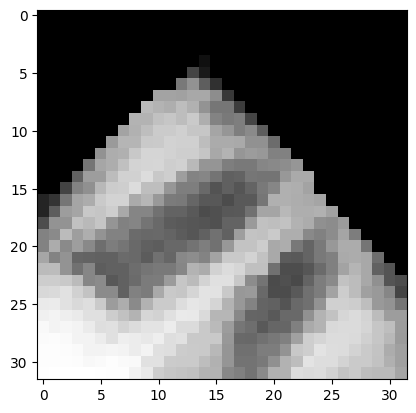

In [ ]:
x_batch, y_batch = next(iter(train_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0), cmap='gray')
print(test_DS.classes[y_batch[0]])

torch.Size([32, 1, 32, 32])
Negative


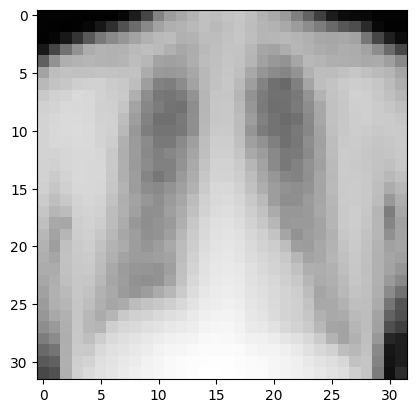

In [ ]:
x_batch, y_batch = next(iter(test_DL))
print(x_batch.shape)
plt.imshow(x_batch[0].permute(1,2,0), cmap='gray')
print(test_DS.classes[y_batch[0]])